# SSAEP Migraine Condition Baseline (self-contained)

Subject-level migraine vs. control detection using the **ssaep** evoked
condition (2-s epochs stored in `data/MIGRAINE_GPU_preprocessed/ssaep/`).

This notebook is **self-contained**: every step (window building, the 42
features, PCA, the 8-model zoo and Leave-One-Subject-Out evaluation) is
implemented inline. No external analysis module is imported.

**Pipeline:**
1. Reconstruct ~20 s windows = 10 contiguous 2-s epochs per window.
2. Extract 42 features/window (relative band power, alpha peak frequency,
   spectral entropy, wPLI connectivity, topographic asymmetry).
3. Standardize + PCA.
4. Train an 8-model zoo and evaluate each with **Leave-One-Subject-Out**,
   reporting window-level and subject-level AUC / accuracy / precision /
   recall / F1.

**Subject exclusions** (same as the resting baseline):
- Medicated (original study): `M2`, `M6`, `M18`
- Unmatched extra controls: `C2`, `C6`, `C12`

**Validation rule:** split by **subject, never by epoch**; labels come from
`Dataset/Migraine_Control_Demographics.xlsx`.


## 1. Setup and data loading

In [ ]:

import os
import re
import glob
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
from scipy import signal as sp_signal
from scipy.stats import entropy as sp_entropy

warnings.filterwarnings('ignore')

PROJECT_ROOT = Path.cwd()                       
PREPROCESSED = PROJECT_ROOT / 'data' / 'MIGRAINE_GPU_preprocessed'
DEMOGRAPHICS = PROJECT_ROOT / 'Dataset' / 'Migraine_Control_Demographics.xlsx'
OUTPUT_DIR   = PROJECT_ROOT / 'output'
OUTPUT_DIR.mkdir(exist_ok=True)

SFREQ= 512.0    
EPOCH_S = 2.0       
WINDOW_EPOCHS= 10        
RANDOM_STATE= 42         


EXCLUDES       = {'M2', 'M6', 'M18'}#took medication before the recording
EXTRA_CONTROLS = {'C2', 'C6', 'C12'}# unmatched extra controls

BANDS = {
    'delta': (0.5, 4.0),
    'theta': (4.0, 8.0),
    'alpha': (8.0, 13.0),
    'beta' : (13.0, 30.0),
    'gamma': (30.0, 100.0),
}
CONN_CHANNELS = [
    'Fp1', 'Fp2', 'AF7', 'AF8',
    'F7', 'F3', 'Fz', 'F4', 'F8',
    'FC5', 'FC1', 'FC2', 'FC6',
    'T7', 'C3', 'Cz', 'C4', 'T8',
    'CP5', 'CP1', 'CP2', 'CP6',
    'P7', 'P3', 'Pz', 'P4', 'P8',
    'PO9', 'O1', 'Oz', 'O2', 'PO10',
]


def load_labels():
    """Return {subject_id: 1 if migraine, 0 if control} from the Excel file."""
    df = pd.read_excel(DEMOGRAPHICS)
    labels = {}
    for _, row in df.iterrows():
        pid = str(row['P#']).strip()
        labels[pid] = 0 if pid.startswith('C') else 1
    return labels


def discover_files(condition):
    """Find every '*_broadband.npy' file inside a condition folder.

    Returns (folder, records) where each record holds the file path plus the
    recording-folder name and the base subject id parsed from the filename.
    """
    cond_dir = PREPROCESSED / condition
    files = sorted(glob.glob(str(cond_dir / '*_broadband.npy')))
    records = []
    for f in files:
        name = os.path.basename(f)
        
        m = re.match(r'^(C\d+|M\d+_\d+)_(.+)_broadband\.npy$', name)
        if not m:
            continue
        subject_dir = m.group(1)                  # the recording folder name
        base_id = subject_dir.split('_')[0]       # base subject id (e.g. M15)
        records.append({'file': f, 'subject_dir': subject_dir, 'base_id': base_id})
    return cond_dir, records


def channel_names():
    """Read the ordered list of EEG channel names (130 channels)."""
    with open(PREPROCESSED / 'channel_names.txt') as fh:
        return [line.strip() for line in fh if line.strip()]


WINDOW_STRIDE = 5          
STIM_FREQS   = [4.0, 6.0]  
N_HARMONICS  = 3           
SNR_BINS     = 4          
WINDOW_STRIDE = 8         
STIM_FREQS   = [4.0, 6.0] 
N_HARMONICS  = 3          
SNR_BINS     = 4           
WINDOW_STRIDE = 8          
STIM_FREQS   = [4.0, 6.0]  
N_HARMONICS  = 3         
SNR_BINS     = 4         


## 2. Feature extraction helpers (42 features per 20-s window)

In [ ]:

import numpy as np
def welch_psd(data, sfreq=SFREQ):
    """Power spectral density via Welch's method (averaged per channel)."""
    freqs, psd = sp_signal.welch(
        data, fs=sfreq, nperseg=int(4 * sfreq), noverlap=int(2 * sfreq), axis=-1)
    return freqs, psd


def band_power_features(psd, freqs):
    """Relative power in each band = band area / total spectrum area."""
    total = np.trapezoid(psd, freqs, axis=-1)
    total[total == 0] = 1e-12
    out = []
    for _, (lo, hi) in BANDS.items():
        mask = (freqs >= lo) & (freqs <= hi)
        bp = np.trapezoid(psd[:, mask], freqs[mask], axis=-1)
        out.append(bp / total)
    return np.stack(out, axis=-1)       


def alpha_peak_frequency(psd, freqs):
    """Frequency (Hz) of the strongest peak inside the 8-13 Hz alpha band."""
    mask = (freqs >= 8.0) & (freqs <= 13.0)
    return freqs[mask][np.argmax(psd[:, mask], axis=-1)]


def spectral_entropy_features(psd):
    """Normalised spectral entropy per channel (0 = flat, 1 = peaky)."""
    p = psd / (psd.sum(axis=-1, keepdims=True) + 1e-12)
    return sp_entropy(p, axis=-1) / np.log(psd.shape[-1])


def wpli_matrix(data):
    """Weighted Phase Lag Index between every pair of channels (n_ch, n_ch)."""
    n_ch = data.shape[0]
    phase = np.angle(sp_signal.hilbert(data, axis=-1))
    wpli = np.zeros((n_ch, n_ch))
    for i in range(n_ch):
        for j in range(i + 1, n_ch):
            imag = np.sin(phase[i] - phase[j])
            num = np.abs(np.mean(imag))
            den = np.mean(np.abs(imag))
            wpli[i, j] = wpli[j, i] = num / (den + 1e-12)
    return wpli


def connectivity_graph_features(wpli):
    """Summarise the wPLI graph with a small set of scalar statistics."""
    n = wpli.shape[0]
    triu = wpli[np.triu_indices(n, k=1)]
    feats = {
        'conn_mean':   triu.mean(),
        'conn_std':    triu.std(),
        'conn_max':    triu.max(),
        'conn_min':    triu.min(),
        'conn_median': np.median(triu),
    }
    w = wpli.copy()
    np.fill_diagonal(w, 0)
    clustering = np.zeros(n)
    for i in range(n):
        neighbours = np.where(w[i] > 0)[0]
        if len(neighbours) < 2:
            continue
        sub = w[np.ix_(neighbours, neighbours)]
        clustering[i] = sub.sum() / (len(neighbours) * (len(neighbours) - 1) + 1e-12)
    feats['conn_clustering'] = clustering.mean()
    return feats


def topographic_asymmetry(band_power, ch_names):
    """Left/right and anterior/posterior power ratios for each band."""
    idx = {ch: i for i, ch in enumerate(ch_names)}
    left  = ['Fp1', 'F7', 'F3', 'T7', 'C3', 'P7', 'P3', 'O1']
    right = ['Fp2', 'F8', 'F4', 'T8', 'C4', 'P8', 'P4', 'O2']
    ant   = ['Fp1', 'Fp2', 'F7', 'F3', 'Fz', 'F4', 'F8']
    post  = ['P7', 'P3', 'Pz', 'P4', 'P8', 'O1', 'O2']
    feats = {}
    for b, band_name in enumerate(BANDS):
        lr = (np.mean([band_power[idx[c], b] for c in left if c in idx]) /
              (np.mean([band_power[idx[c], b] for c in right if c in idx]) + 1e-12))
        ap = (np.mean([band_power[idx[c], b] for c in ant if c in idx]) /
              (np.mean([band_power[idx[c], b] for c in post if c in idx]) + 1e-12))
        feats[f'LR_{band_name}'] = lr
        feats[f'AP_{band_name}'] = ap
    return feats


def steady_state_features(epochs, sfreq=SFREQ):
    """Trial-based SSAEP/SSVEP response features from (n_epochs, n_ch, n_time).

    Computed per driving frequency (4 and 6 Hz) and its harmonics:
      - amplitude of the phase-locked (steady-state) response
      - signal-to-noise ratio against the neighbouring noise floor
      - inter-trial phase coherence (ITPC): consistency of phase across epochs
      - habituation slope: linear regression of response amplitude vs trial index
    """
    n_epochs, n_ch, n_time = epochs.shape
    fftfreqs = np.fft.rfftfreq(n_time, d=1.0 / sfreq)
    df = sfreq / n_time
    win = np.hanning(n_time)
    spec = np.fft.rfft(epochs * win, axis=-1)      
    amps = np.abs(spec)

    noise_mask = np.ones(len(fftfreqs), dtype=bool)
    noise_mask[: max(1, int(2.0 / df))] = False      

    feats = {}
    for f0 in STIM_FREQS:
        for h in range(1, N_HARMONICS + 1):
            freq = f0 * h
            target = int(round(freq / df))
            if target < 1 or target >= len(fftfreqs) - 1:
                continue
            sig = amps[:, :, target - 1:target + 2].mean(axis=-1)  
            guard_lo = max(0, target - 6)
            guard_hi = min(len(fftfreqs), target + 7)
            nmask = noise_mask.copy()
            nmask[guard_lo:guard_hi] = False
            noise = amps[:, :, nmask].mean(axis=-1)                 
            snr = (sig + 1e-12) / (noise + 1e-12)

            bin_phase = np.angle(spec[:, :, target])
            itpc = np.abs(np.mean(np.exp(1j * bin_phase), axis=0))  

            x = np.arange(n_epochs, dtype=np.float64)
            xm = x - x.mean()
            denom = np.sum(xm ** 2) + 1e-12
            slope = np.sum(xm[:, None] * (sig - sig.mean(axis=0)), axis=0) / denom

            tag = f'ss{f0:g}' if h == 1 else f'ss{f0:g}_h{h}'
            feats[f'{tag}_amp']   = float(np.log1p(np.mean(sig)))
            feats[f'{tag}_snr']   = float(np.log1p(np.mean(snr)))
            feats[f'{tag}_itpc']  = float(np.mean(itpc))
            feats[f'{tag}_slope'] = float(np.mean(slope))
    return feats


def extract_window_features(window_data, epochs, ch_names):
    """Turn one window (channels x time) + its epochs into a feature dict."""
    feats = {}
    freqs, psd = welch_psd(window_data)
    bp  = band_power_features(psd, freqs)          
    apf = alpha_peak_frequency(psd, freqs)
    se  = spectral_entropy_features(psd)


    for b, band_name in enumerate(BANDS):
        feats[f'bp_{band_name}_mean'] = np.log1p(bp[:, b].mean())
        feats[f'bp_{band_name}_std']  = np.log1p(bp[:, b].std())
        feats[f'bp_{band_name}_max']  = np.log1p(bp[:, b].max())
        feats[f'bp_{band_name}_min']  = np.log1p(bp[:, b].min())


    feats['apf_mean'] = apf.mean(); feats['apf_std'] = apf.std()
    feats['apf_max']  = apf.max();  feats['apf_min'] = apf.min()
    feats['se_mean']  = se.mean();  feats['se_std']  = se.std()

    #wPLI connectivity on the 32-channel subset (if enough channels exist)
    conn_idx = [ch_names.index(c) for c in CONN_CHANNELS if c in ch_names]
    if len(conn_idx) >= 16:
        feats.update(connectivity_graph_features(wpli_matrix(window_data[conn_idx])))

    #topographic asymmetry ratios
    feats.update(topographic_asymmetry(bp, ch_names))

    # Steady-state (stimulus-locked) response features computed per epoch
    feats.update(steady_state_features(epochs))
    return feats


def build_dataset(condition):
    """Extract per-window features for one condition using overlapping windows.

    Returns: X (n_windows x n_features), y (labels), groups (subject per window),
    feat_names, subject_stats (DataFrame), n_skipped (dropped recordings).
    """
    _, records = discover_files(condition)
    labels = load_labels()
    chs = channel_names()

    X_list, y_list, groups_list = [], [], []
    feat_names, subject_stats = None, []
    n_skipped = 0

    for r in records:
        base = r['base_id']
        if base in EXCLUDES or base in EXTRA_CONTROLS or base not in labels:
            n_skipped += 1
            continue
        arr = np.load(r['file'])                    
        if arr.shape[0] == 0:
            n_skipped += 1
            continue
        n_epochs = arr.shape[0]
        n_windows = max(0, (n_epochs - WINDOW_EPOCHS) // WINDOW_STRIDE + 1)
        if n_windows == 0:
            n_skipped += 1
            continue
        for w in range(n_windows):
            start = w * WINDOW_STRIDE
            end   = start + WINDOW_EPOCHS
            epochs = arr[start:end]                    
            window_data = epochs.transpose(1, 0, 2).reshape(arr.shape[1], -1)
            feats = extract_window_features(window_data, epochs, chs)
            if feat_names is None:
                feat_names = list(feats.keys())
            X_list.append(list(feats.values()))
            y_list.append(labels[base])
            groups_list.append(r['subject_dir'])
        subject_stats.append({
            'subject': r['subject_dir'],
            'group': 'migraine' if labels[base] == 1 else 'control',
            'n_epochs': int(n_epochs),
            'n_windows': n_windows,
        })

    X = np.array(X_list, dtype=np.float64)
    y = np.array(y_list)
    groups = np.array(groups_list)
    return X, y, groups, feat_names, pd.DataFrame(subject_stats), n_skipped


## 3. Models and evaluation helpers

In [ ]:

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (RandomForestClassifier, ExtraTreesClassifier,
                              GradientBoostingClassifier, VotingClassifier)
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier

from sklearn.model_selection import LeaveOneGroupOut, GroupKFold
from sklearn.metrics import (roc_auc_score, accuracy_score, precision_score,
                             recall_score, f1_score, confusion_matrix, roc_curve)


def balanced_weights(y):
    """Per-sample weights so both classes contribute equally during training."""
    bins = np.bincount(y)
    w = np.ones(len(y), dtype=float)
    for c in np.unique(y):
        if bins[c] > 0:
            w[y == c] = len(y) / float(2.0 * bins[c])
    return w


class WKNN(KNeighborsClassifier):
    """KNN wrapper that accepts (and ignores) the sample_weight argument so the
    same balanced-training call works for every model in the zoo."""

    def fit(self, X, y, sample_weight=None):
        return super().fit(X, y)


MODEL_ZOO = {
    'LogisticRegression': lambda: LogisticRegression(C=1.0, max_iter=3000,
                                                     random_state=RANDOM_STATE),
    'RandomForest': lambda: RandomForestClassifier(n_estimators=300, max_depth=8,
                                                   random_state=RANDOM_STATE),
    'ExtraTrees': lambda: ExtraTreesClassifier(n_estimators=300, max_depth=8,
                                               random_state=RANDOM_STATE),
    'GradientBoosting': lambda: GradientBoostingClassifier(n_estimators=200,
                                        learning_rate=0.05, max_depth=3,
                                        random_state=RANDOM_STATE),
    'SVM_RBF': lambda: SVC(C=1.0, kernel='rbf', gamma='scale', probability=True,
                           random_state=RANDOM_STATE),
    'KNN': lambda: WKNN(n_neighbors=7),
    'GaussianNB': lambda: GaussianNB(),
    'MLP': lambda: MLPClassifier(hidden_layer_sizes=(64,), max_iter=800,
                                 early_stopping=True, random_state=RANDOM_STATE),
    'VotingEnsemble': lambda: VotingClassifier(
        estimators=[
            ('lr',  LogisticRegression(C=1.0, max_iter=3000, random_state=RANDOM_STATE)),
            ('rf',  RandomForestClassifier(n_estimators=200, max_depth=6, random_state=RANDOM_STATE)),
            ('svm', SVC(C=1.0, kernel='rbf', gamma='scale', probability=True, random_state=RANDOM_STATE)),
            ('kn',  WKNN(n_neighbors=7)),
            ('nb',  GaussianNB()),
        ], voting='soft'),
}


def standardize_pca(X):
    """Standardise features (zero mean, unit variance) then apply PCA."""
    scaler = StandardScaler()
    Xs = scaler.fit_transform(X)
    n_comp = min(60, X.shape[1], X.shape[0])
    pca = PCA(n_components=n_comp, random_state=RANDOM_STATE)
    Xp = pca.fit_transform(Xs)
    return Xp, scaler, pca, float(pca.explained_variance_ratio_.sum())


def evaluate_metrics(prob, true):
    """AUC + accuracy/precision/recall/F1 at the Youden-optimal threshold."""
    fpr, tpr, thr = roc_curve(true, prob)
    best_thr = float(thr[np.argmax(tpr - fpr)])   # maximises sensitivity + specificity
    pred = (prob >= best_thr).astype(int)
    tn, fp, fn, tp = confusion_matrix(true, pred).ravel()
    return {
        'subject_auc':      float(roc_auc_score(true, prob)),
        'subject_accuracy': float(accuracy_score(true, pred)),
        'subject_precision': float(precision_score(true, pred, zero_division=0)),
        'subject_recall':   float(recall_score(true, pred, zero_division=0)),
        'subject_f1':       float(f1_score(true, pred, zero_division=0)),
        'youden_threshold': best_thr,
        'cm': [[int(tn), int(fp)], [int(fn), int(tp)]],
        'roc': (fpr, tpr),
    }


def evaluate_loso(builder, X, y, groups):
    """Leave-One-Subject-Out: every subject is the test set exactly once."""
    logo = LeaveOneGroupOut()
    fold_aucs = []
    subj_prob, subj_true = {}, {}
    for tr, te in logo.split(X, y, groups):
        clf = builder()
        clf.fit(X[tr], y[tr], sample_weight=balanced_weights(y[tr]))
        prob = clf.predict_proba(X[te])[:, 1]
        fold_aucs.append(roc_auc_score(y[te], prob))
        grp = groups[te][0]
        subj_prob.setdefault(grp, []).append(prob)
        subj_true[grp] = y[te][0]

    order = sorted(subj_prob)
    prob_arr = np.array([np.mean(np.concatenate(subj_prob[g])) for g in order])
    true_arr = np.array([subj_true[g] for g in order])

    res = evaluate_metrics(prob_arr, true_arr)
    res['window_auc'] = float(np.mean(fold_aucs))
    res['window_auc_std'] = float(np.std(fold_aucs))
    res['n_subjects'] = len(order)
    res['n_migraine'] = int(true_arr.sum())
    res['subjects'] = order
    res['subject_probs'] = prob_arr
    res['subject_true'] = true_arr
    return res


def grouped_window_auc(builder, X, y, groups, splits=5):
    """Window-level AUC via grouped 5-fold CV (each fold holds out whole subjects)."""
    gkf = GroupKFold(n_splits=splits)
    aucs = []
    for tr, te in gkf.split(X, y, groups):
        clf = builder()
        clf.fit(X[tr], y[tr], sample_weight=balanced_weights(y[tr]))
        prob = clf.predict_proba(X[te])[:, 1]
        try:
            aucs.append(roc_auc_score(y[te], prob))
        except Exception:
            continue
    if not aucs:
        return float('nan'), float('nan')
    return float(np.mean(aucs)), float(np.std(aucs))


def run_all_models(X, y, groups):
    """Run every model in MODEL_ZOO -> (results DataFrame, ROC data dict)."""
    rows, roc_data = [], {}
    for name, builder in MODEL_ZOO.items():
        res = evaluate_loso(builder, X, y, groups)
        wa, wastd = grouped_window_auc(builder, X, y, groups)
        fpr, tpr = res['roc']
        rows.append({
            'model': name,
            'window_auc': wa, 'window_auc_std': wastd,
            'subject_auc': res['subject_auc'],
            'subject_accuracy': res['subject_accuracy'],
            'subject_precision': res['subject_precision'],
            'subject_recall': res['subject_recall'],
            'subject_f1': res['subject_f1'],
            'youden_threshold': res['youden_threshold'],
            'n_subjects': res['n_subjects'], 'n_migraine': res['n_migraine'],
            'cm_tn': res['cm'][0][0], 'cm_fp': res['cm'][0][1],
            'cm_fn': res['cm'][1][0], 'cm_tp': res['cm'][1][1],
        })
        roc_data[name] = (fpr, tpr, res['subject_auc'])
    return pd.DataFrame(rows), roc_data


## 4. Build the per-window feature dataset

In [4]:
# --- Build the per-window feature dataset for this condition ---
COND = 'ssaep'
X, y, groups, feat_names, subj_stats, n_skipped = build_dataset(COND)
print(f'Windows: {X.shape[0]} | Features per window: {X.shape[1]} ({len(feat_names)} names)')
print(f'Skipped recordings (excluded/empty): {n_skipped}')
print(f'Migraine windows: {(y == 1).sum()} | Control windows: {(y == 0).sum()}')
print(f'Subjects used: {len(subj_stats)}')
print(subj_stats.head(15))


Windows: 1090 | Features per window: 42 (42 names)
Skipped recordings (excluded/empty): 6
Migraine windows: 459 | Control windows: 631
Subjects used: 33
   subject    group  n_epochs  n_windows
0      C10  control       401         40
1      C11  control       364         36
2      C13  control       365         36
3      C14  control        79          7
4      C14  control       212         21
5      C15  control       374         37
6      C16  control       347         34
7      C17  control       351         35
8      C18  control       367         36
9      C19  control       356         35
10      C1  control       381         38
11     C20  control       336         33
12     C21  control       350         35
13      C3  control       324         32
14      C4  control       397         39


## 5. Standardize + PCA

In [5]:

Xp, scaler, pca, cumvar = standardize_pca(X)
print(f'PCA -> {Xp.shape[1]} components, explained variance = {cumvar:.3f}')


PCA -> 42 components, explained variance = 1.000


## 6. Model zoo - Leave-One-Subject-Out

In [6]:

results_df, roc_data = run_all_models(Xp, y, groups)
print(results_df[['model', 'window_auc', 'subject_auc', 'subject_accuracy',
                  'subject_precision', 'subject_recall', 'subject_f1',
                  'n_subjects']].to_string(index=False))


             model  window_auc  subject_auc  subject_accuracy  subject_precision  subject_recall  subject_f1  n_subjects
LogisticRegression    0.378507     0.269841           0.56250           0.000000        0.000000    0.000000          32
      RandomForest    0.442395     0.353175           0.46875           0.451613        1.000000    0.622222          32
        ExtraTrees    0.431158     0.305556           0.56250           0.000000        0.000000    0.000000          32
  GradientBoosting    0.397595     0.373016           0.46875           0.451613        1.000000    0.622222          32
           SVM_RBF    0.419633     0.317460           0.59375           1.000000        0.071429    0.133333          32
               KNN    0.425219     0.345238           0.53125           0.481481        0.928571    0.634146          32
        GaussianNB    0.477598     0.527778           0.62500           0.600000        0.428571    0.500000          32
               MLP    0.405075  

## 7. ROC curves

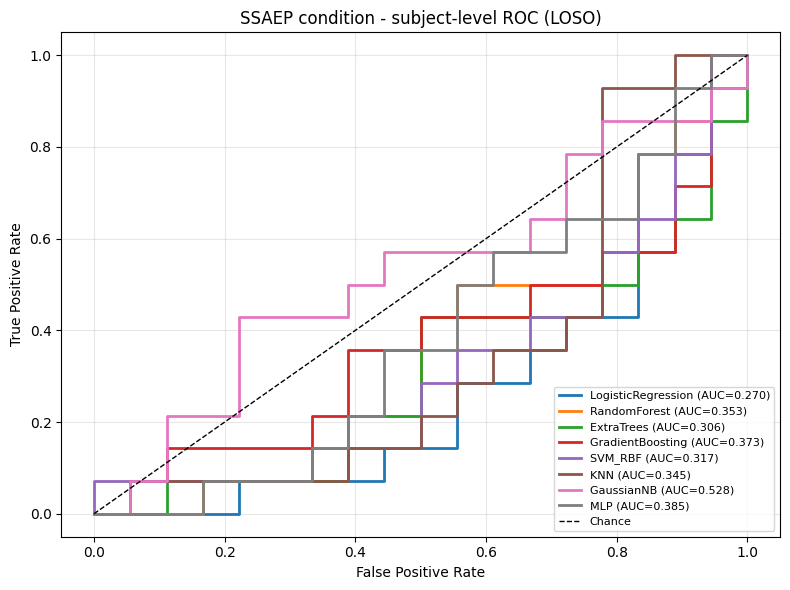

In [7]:
# --- Plot subject-level ROC curves for every model --------------------------
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
for name, (fpr, tpr, auc) in roc_data.items():
    plt.plot(fpr, tpr, lw=2, label=f'{name} (AUC={auc:.3f})')
plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Chance')
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('SSAEP condition - subject-level ROC (LOSO)')
plt.legend(loc='lower right', fontsize=8); plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'ssaep_baseline_roc.png', dpi=150)
plt.show()


## 8. Save results

In [ ]:
# --- Save the results table and print a chance-level reference --------------
out = OUTPUT_DIR / 'ssaep_baseline_results.csv'
results_df.to_csv(out, index=False)
print('Saved results ->', out)

# Chance-level reference (Combrisson & Jerbi 2015)
n = int(results_df['n_subjects'].iloc[0])
mi = int(results_df['n_migraine'].iloc[0])
se = (0.5 * 0.5 / n) ** 0.5
print(f'Chance accuracy = 0.500, 95% CI = [{0.5 - 1.96 * se:.3f}, {0.5 + 1.96 * se:.3f}]')
print(f'Subjects: n={n} (migraine={mi}, control={n - mi})')


## Notes
- **Subject-level** metrics come from Leave-One-Subject-Out (LOSO).
- **Window-level AUC** uses grouped 5-fold cross-validation (each test fold holds
  out whole subjects). Per-subject LOSO test folds are single-class, so window
  AUC is not defined there.
- Accuracy / precision / recall / F1 are computed at the Youden-optimal threshold
  for each model's subject-level score.
- Windows are always split by subject, so there is no per-epoch leakage.
- This is a **subject-level feasibility pilot on a small cohort**, not clinical
  generalization. Nested CV / external validation are required for any claim.
